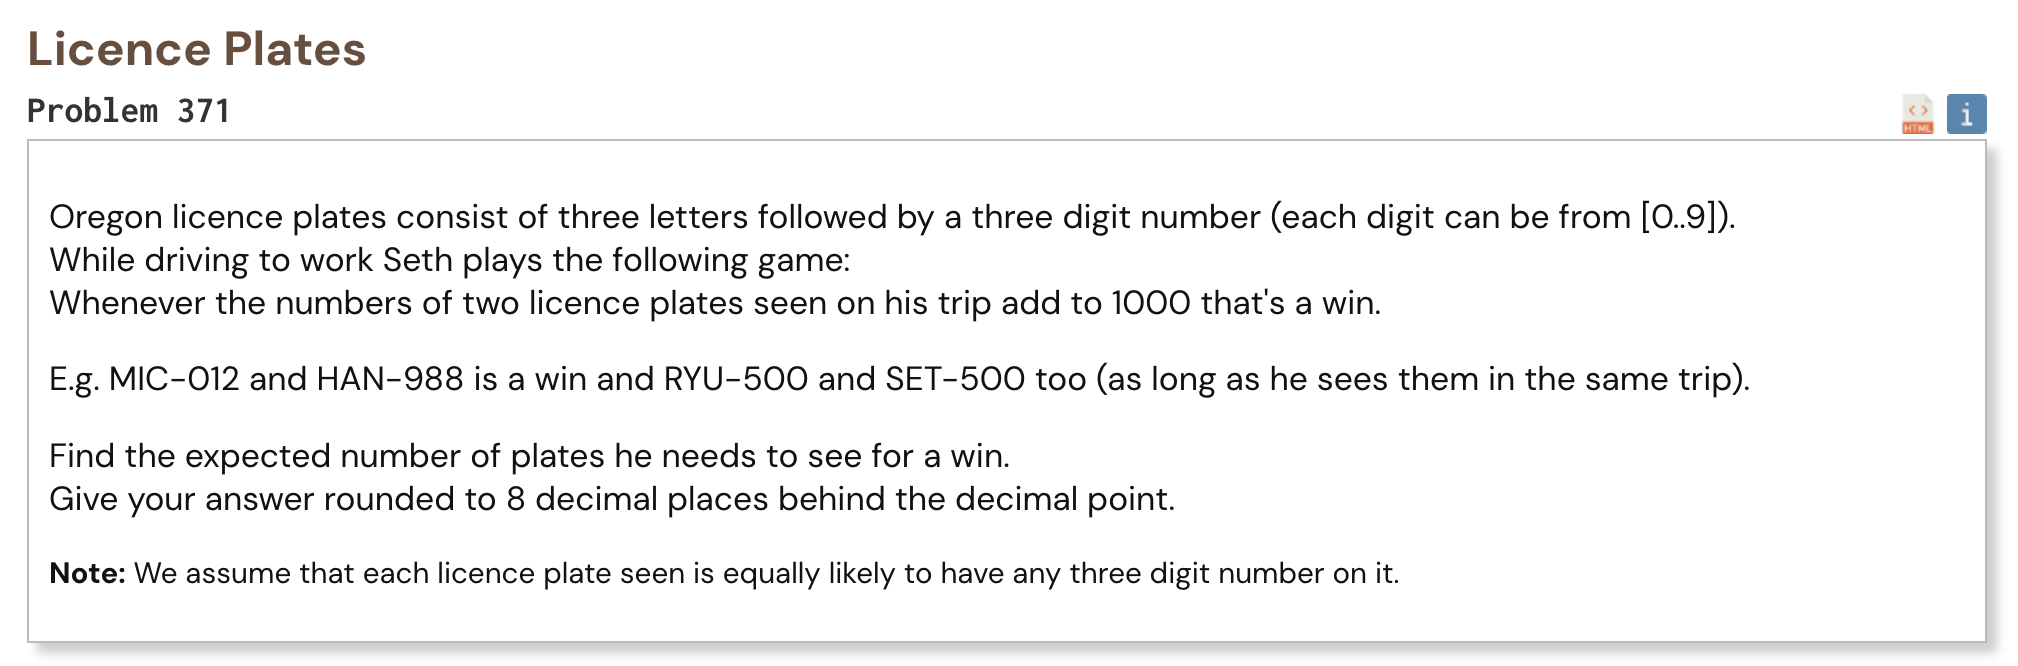

## Initial approach

* ignore the letters because only the three-digit numbers affect the game
* group the numbers into 499 complementary pairs plus the special case 500
* define the state by how many complement pairs have exactly one number already seen and whether 500 has appeared
* compute the expected remaining plates for every state using dynamic programming
* fill the states from the largest number of open pairs down to zero so each transition is already known
* avoid recursion completely by using an iterative table
* the answer is the expectation from the initial state with no open pairs and 500 not yet seen

In [1]:
def solve():
    total_numbers = 1000
    pair_count = 499

    expected_seen_500 = [0.0] * (pair_count + 1)
    expected_not_seen_500 = [0.0] * (pair_count + 1)

    for open_pairs in range(pair_count, -1, -1):
        dangerous = open_pairs + 1
        safe_new_pair = 2 * (pair_count - open_pairs)
        safe_repeat = total_numbers - dangerous - safe_new_pair

        value = 1.0

        if safe_new_pair:
            value += safe_new_pair / total_numbers * expected_seen_500[open_pairs + 1]

        expected_seen_500[open_pairs] = value / (1 - safe_repeat / total_numbers)

        dangerous = open_pairs
        safe_new_pair = 2 * (pair_count - open_pairs)
        safe_repeat = total_numbers - dangerous - safe_new_pair - 1

        value = 1.0

        if safe_new_pair:
            value += safe_new_pair / total_numbers * expected_not_seen_500[open_pairs + 1]

        value += 1 / total_numbers * expected_seen_500[open_pairs]

        expected_not_seen_500[open_pairs] = value / (1 - safe_repeat / total_numbers)

    return expected_not_seen_500[0]

In [2]:
%%time
result = solve()
print("Result:", f"{result:.8f}")

Result: 40.66368097
CPU times: user 442 μs, sys: 7 μs, total: 449 μs
Wall time: 447 μs
